# Prediksi Produktivitas (Kelayakan) Lahan Padi

Klasifikasi tiga kelas (Rendah, Sedang, Tinggi) berdasarkan produktivitas lahan, yaitu hasil panen per hektar. Logistic Regression dipakai sebagai baseline dan Random Forest sebagai model utama, semuanya di dalam pipeline agar bebas kebocoran data. Jumlah fitur ditekan lewat seleksi supaya aplikasi penyuluh tidak perlu meminta puluhan input.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 1. Data input

In [3]:
df = pd.read_csv('paddydataset.csv')
df.columns = df.columns.str.strip()

yph = df['Paddy yield(in Kg)'] / df['Hectares']

bocor = ['Paddy yield(in Kg)', 'Hectares',
         'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)', 'Nursery area (Cents)',
         'LP_nurseryarea(in Tonnes)', 'DAP_20days', 'Weed28D_thiobencarb',
         'Urea_40Days', 'Potassh_50Days', 'Micronutrients_70Days', 'Pest_60Day(in ml)',
         'Trash(in bundles)']
X = df.drop(columns=bocor)
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

print(f"{X.shape[1]} fitur dipakai ({len(num_cols)} numerik, {len(cat_cols)} kategorik); "
      f"{len(bocor)} kolom dibuang")

df.head(10)

32 fitur dipakai (24 numerik, 8 kategorik); 13 kolom dibuang


,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,Weed28D_thiobencarb,Urea_40Days,Potassh_50Days,Micronutrients_70Days,Pest_60Day(in ml),30DRain( in mm),30DAI(in mm),30_50DRain( in mm),30_50DAI(in mm),51_70DRain(in mm),51_70AI(in mm),71_105DRain(in mm),71_105DAI(in mm),Min temp_D1_D30,Max temp_D1_D30,Min temp_D31_D60,Max temp_D31_D60,Min temp_D61_D90,Max temp_D61_D90,Min temp_D91_D120,Max temp_D91_D120,Inst Wind Speed_D1_D30(in Knots),Inst Wind Speed_D31_D60(in Knots),Inst Wind Speed_D61_D90(in Knots),Inst Wind Speed_D91_D120(in Knots),Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,12,162.78,62.28,90,3600,19.6,20.4,187.2,270.8,167.0,250.0,61.0,64.0,18.5,34,16.0,30,15.5,31.0,16.0,33.0,4,10,8,10,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,12,162.78,62.28,90,3600,19.6,20.4,187.2,270.8,167.0,250.0,61.0,64.0,19.5,34,18.5,35,17.0,32.5,16.0,30.5,10,4,10,6,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,12,162.78,62.28,90,3600,18.5,21.5,185.2,272.8,165.3,251.7,60.0,65.0,20.0,35,18.0,30,17.5,33.5,18.0,33.0,4,12,4,12,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,12,162.78,62.28,90,3600,18.5,21.5,185.2,272.8,165.3,251.7,60.0,65.0,19.0,33,17.0,32,16.5,31.5,15.5,32.5,8,6,8,6,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,12,162.78,62.28,90,3600,18.1,21.9,185.6,272.4,166.1,250.9,60.2,64.8,20.5,32,17.5,28,18.0,34.0,16.5,35.0,10,12,10,12,SSE,W,SW,NW,72.7,91,83,81,600,34044
5,6,Chinnasalem,delux ponni,alluvial,150,75.0,wet,120,6,240,12,162.78,62.28,90,3600,18.1,21.9,185.6,272.4,166.1,250.9,60.2,64.8,18.0,31,15.5,34,15.0,33.0,15.0,31.5,6,6,8,10,E,ENE,NE,NNW,78.6,80,92,88,480,36732
6,6,Cuddalore,CO_43,clay,150,75.0,wet,120,6,240,12,162.78,62.28,90,3600,19.6,20.4,187.2,270.8,167.0,250.0,61.0,64.0,18.5,34,16.0,30,15.5,31.0,16.0,33.0,4,10,8,10,SW,W,NNW,WSW,72.0,78,88,85,540,33162
7,6,Kurinjipadi,delux ponni,alluvial,150,75.0,dry,120,6,240,12,162.78,62.28,90,3600,19.6,20.4,187.2,270.8,167.0,250.0,61.0,64.0,19.5,34,18.5,35,17.0,32.5,16.0,30.5,10,4,10,6,NW,S,SE,SSE,64.6,85,84,87,480,36690
8,6,Panruti,ponmani,clay,150,75.0,dry,120,6,240,12,162.78,62.28,90,3600,18.5,21.5,185.2,272.8,165.3,251.7,60.0,65.0,20.0,35,18.0,30,17.5,33.5,18.0,33.0,4,12,4,12,ENE,NE,NNE,W,85.0,96,84,79,600,35310
9,6,Kallakurichi,CO_43,alluvial,150,75.0,dry,120,6,240,12,162.78,62.28,90,3600,18.5,21.5,185.2,272.8,165.3,251.7,60.0,65.0,19.0,33,17.0,32,16.5,31.5,15.5,32.5,8,6,8,6,W,WNW,SE,S,88.5,95,81,84,540,32460


## 2. data split



In [4]:
CLASS_ORDER = ['Rendah', 'Sedang', 'Tinggi']

strat = pd.qcut(yph, 3, labels=False, duplicates='drop')

X_train, X_test, yph_train, yph_test = train_test_split(
    X, yph, test_size=0.2, random_state=42, stratify=strat
)

q33, q66 = yph_train.quantile([1/3, 2/3])

def buat_label(v):
    kondisi = [v <= q33, v <= q66]
    pilihan = ['Rendah', 'Sedang']
    
    hasil_teks = np.select(kondisi, pilihan, default='Tinggi')
    return pd.Series(hasil_teks, index=v.index)

y_train = buat_label(yph_train)
y_test  = buat_label(yph_test)
df['Kelayakan'] = buat_label(yph).values   

print(f"Train : {len(X_train)}")
print(f"Test  : {len(X_test)}")


print(f"q33 = {q33:,.0f} Kg")
print(f"q66 = {q66:,.0f} Kg\n")

print("Distribusi Kelas (y_train):")
print(y_train.value_counts().reindex(CLASS_ORDER).to_string())

Train : 2231
Test  : 558
q33 = 5,855 Kg
q66 = 6,181 Kg

Distribusi Kelas (y_train):
Rendah    749
Sedang    764
Tinggi    718


## 3. EDA


In [5]:
df.info()
hilang = df.isnull().sum()
print(f"data hilang:{hilang}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2789 entries, 0 to 2788
Data columns (total 46 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Hectares                            2789 non-null   int64  
 1   Agriblock                           2789 non-null   object 
 2   Variety                             2789 non-null   object 
 3   Soil Types                          2789 non-null   object 
 4   Seedrate(in Kg)                     2789 non-null   int64  
 5   LP_Mainfield(in Tonnes)             2789 non-null   float64
 6   Nursery                             2789 non-null   object 
 7   Nursery area (Cents)                2789 non-null   int64  
 8   LP_nurseryarea(in Tonnes)           2789 non-null   int64  
 9   DAP_20days                          2789 non-null   int64  
 10  Weed28D_thiobencarb                 2789 non-null   int64  
 11  Urea_40Days                         2789 no

In [6]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
30DRain( in mm),2789.0,18.723593,0.643789,18.1,18.1,18.5,19.6,19.6
30DAI(in mm),2789.0,21.276407,0.643789,20.4,20.4,21.5,21.9,21.9
30_50DRain( in mm),2789.0,186.016780,0.856609,185.2,185.2,185.6,187.2,187.2
30_50DAI(in mm),2789.0,271.983220,0.856609,270.8,270.8,272.4,272.8,272.8
51_70DRain(in mm),2789.0,166.161671,0.678601,165.3,165.3,166.1,167.0,167.0
51_70AI(in mm),2789.0,250.838329,0.678601,250.0,250.0,250.9,251.7,251.7
71_105DRain(in mm),2789.0,60.408390,0.428304,60.0,60.0,60.2,61.0,61.0
71_105DAI(in mm),2789.0,64.591610,0.428304,64.0,64.0,64.8,65.0,65.0
Min temp_D1_D30,2789.0,19.337218,0.870589,18.0,18.5,19.5,20.0,20.5
Max temp_D1_D30,2789.0,33.129437,1.316798,31.0,32.0,33.0,34.0,35.0


Sementara train menggunakan random forest untuk cek top feature yang paling berpengaruh

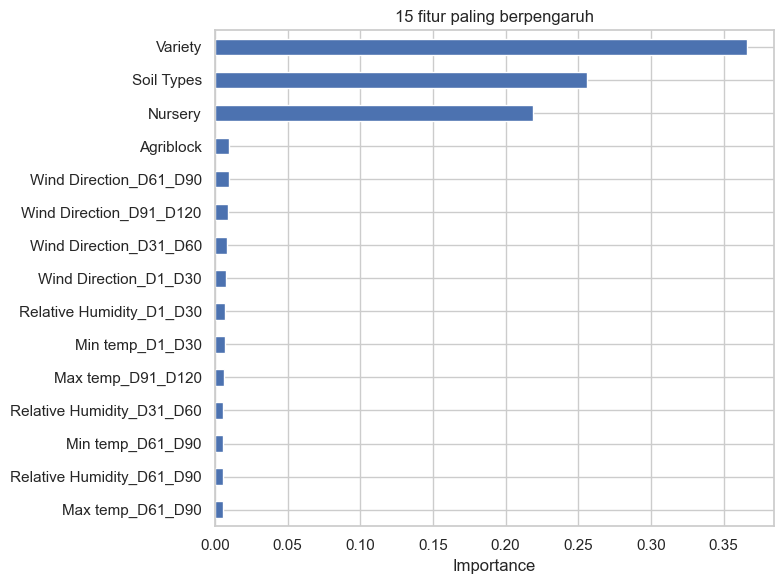

In [7]:
def make_preprocessor(features):
    nums = [c for c in features if c in num_cols]
    cats = [c for c in features if c in cat_cols]
    parts = []
    if nums:
        parts.append(('num', StandardScaler(), nums))
    if cats:
        parts.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cats))
    return ColumnTransformer(parts)

def importance_per_fitur(prep, imp, features):
    nums = [c for c in features if c in num_cols]
    cats = [c for c in features if c in cat_cols]
    out, i = {}, 0
    for c in nums:
        out[c] = imp[i]; i += 1
    if cats:
        for c, kategori in zip(cats, prep.named_transformers_['cat'].categories_):
            out[c] = imp[i:i + len(kategori)].sum(); i += len(kategori)
    return pd.Series(out).sort_values(ascending=False)

probe = Pipeline([('prep', make_preprocessor(list(X.columns))),
                  ('rf', RandomForestClassifier(n_estimators=200, random_state=42,
                                                class_weight='balanced', n_jobs=-1))])
probe.fit(X_train, y_train)
importance = importance_per_fitur(probe['prep'], probe['rf'].feature_importances_, list(X.columns))

importance.head(15)[::-1].plot.barh(figsize=(8, 6))
plt.xlabel('Importance'); plt.title('15 fitur paling berpengaruh')
plt.tight_layout(); plt.show()

Correlation heatmap berdasarkan 15 fitur paling berpengaruh

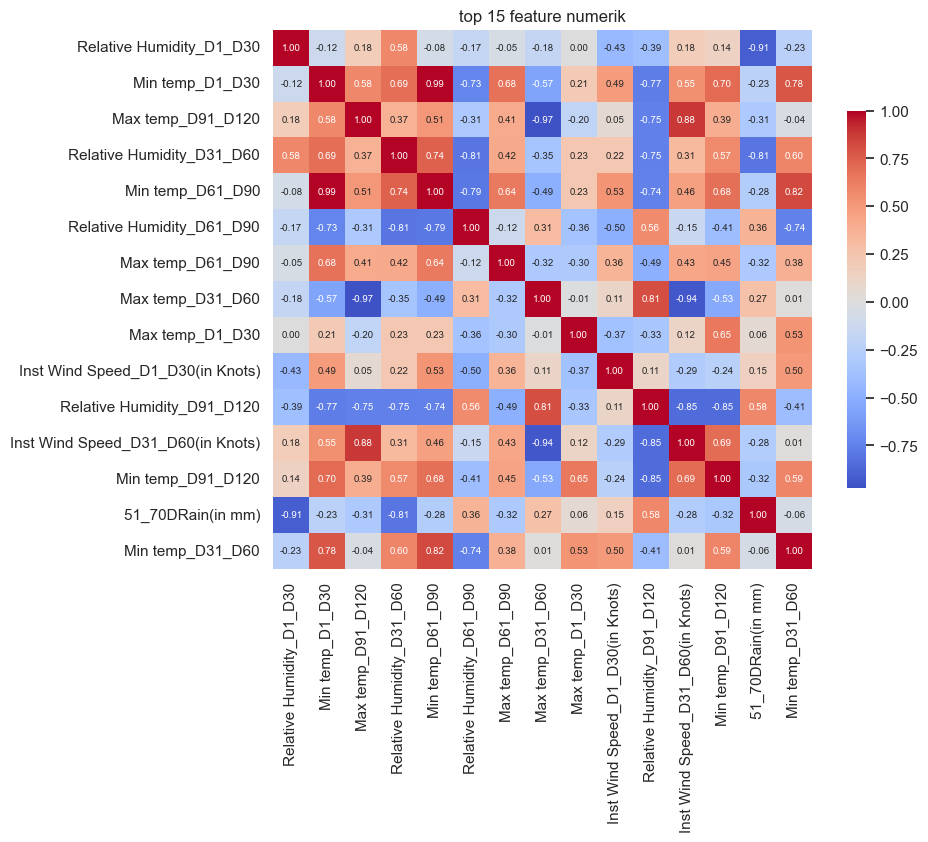

Pasangan dengan korelasi di atas 0,7:
30_50DRain( in mm)                 30_50DAI(in mm)                       1.000
30_50DAI(in mm)                    71_105DAI(in mm)                      1.000
30_50DRain( in mm)                 71_105DAI(in mm)                      1.000
30DRain( in mm)                    30DAI(in mm)                          1.000
51_70DRain(in mm)                  51_70AI(in mm)                        1.000
30_50DRain( in mm)                 71_105DRain(in mm)                    1.000
71_105DRain(in mm)                 71_105DAI(in mm)                      1.000
30_50DAI(in mm)                    71_105DRain(in mm)                    1.000
Min temp_D1_D30                    Min temp_D61_D90                      0.993
Max temp_D31_D60                   Max temp_D91_D120                     0.972
30_50DAI(in mm)                    51_70AI(in mm)                        0.953
                                   51_70DRain(in mm)                     0.953
51_70DRain(in 

In [8]:
top_num = [c for c in importance.index if c in num_cols][:15]

plt.figure(figsize=(9, 7))
sns.heatmap(df[top_num].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, annot_kws={'size': 7}, cbar_kws={'shrink': 0.7})
plt.title('top 15 feature numerik')
plt.show()

corr = df[num_cols].corr().abs()
pasangan = corr.where(np.triu(np.ones(corr.shape, bool), 1)).stack().sort_values(ascending=False)
tinggi = pasangan[pasangan > 0.7]
if len(tinggi):
    print("Pasangan dengan korelasi di atas 0,7:")
    print(tinggi.round(3).to_string())
else:
    print("Tidak ada pasangan di atas 0,7. Lima tertinggi:")
    print(pasangan.head(5).round(3).to_string())

Visualisasi untuk numeric feature

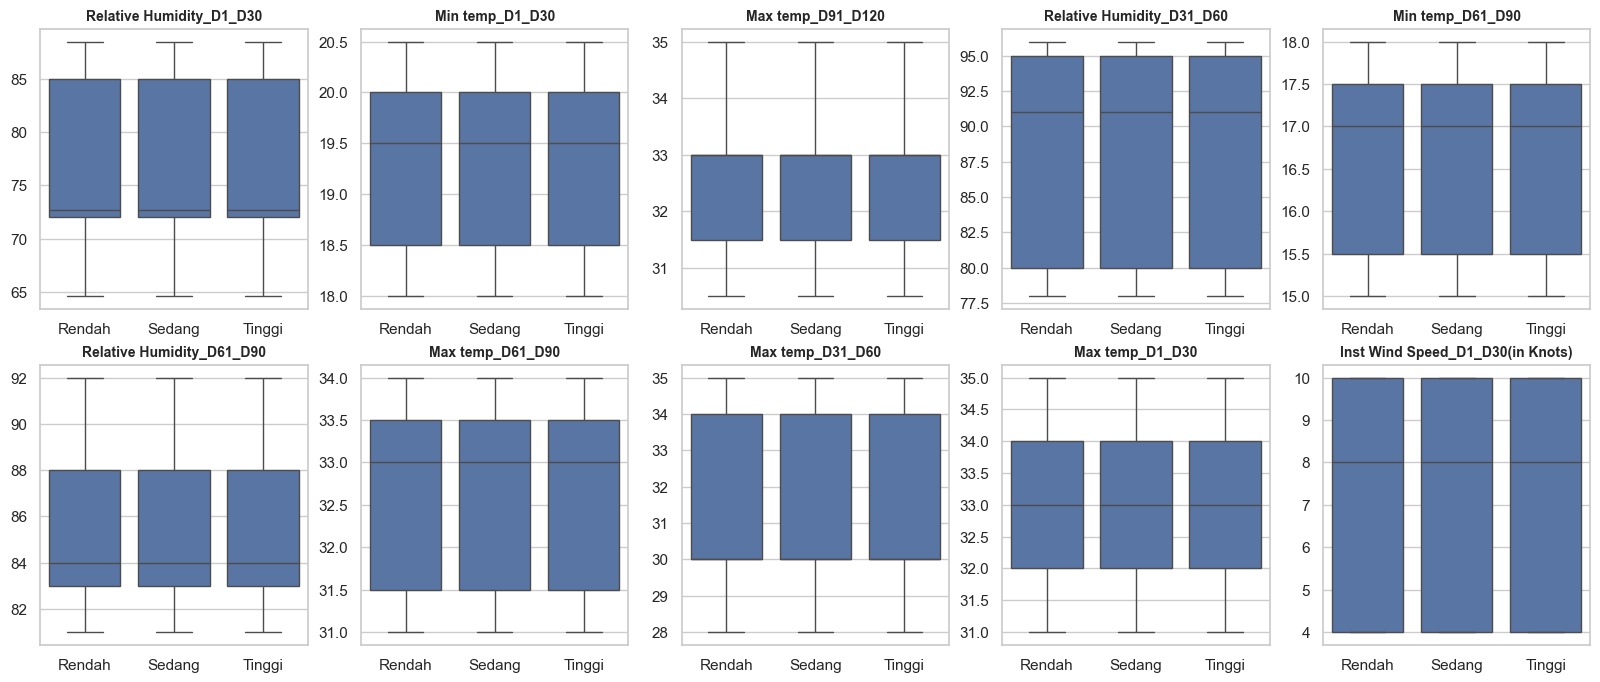

In [9]:
box_feats = [c for c in importance.index if c in num_cols][:10]
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8))

for ax, col in zip(axes.ravel(), box_feats):
    sns.boxplot(
        data=df, 
        x='Kelayakan', 
        y=col, 
        order=CLASS_ORDER, 
        ax=ax
    )
    
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

sisa_kanvas = axes.ravel()[len(box_feats):]
for ax in sisa_kanvas:
    ax.set_visible(False)

plt.show()

Visualisasi untuk feature kategori

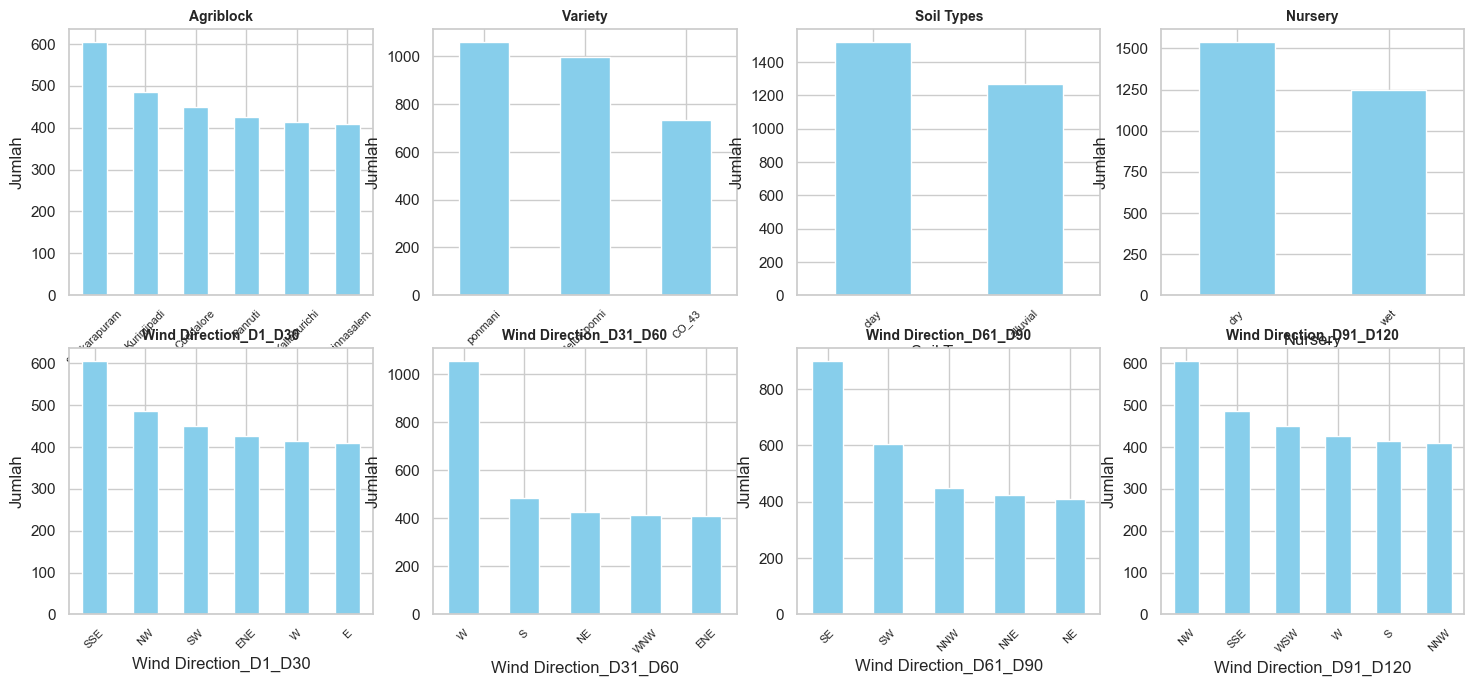

In [10]:
if cat_cols:
    ncol = min(4, len(cat_cols))
    nrow = int(np.ceil(len(cat_cols) / ncol))
    
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.5 * ncol, 3.8 * nrow))
    axes = np.atleast_1d(axes).ravel()
    
    for ax, col in zip(axes, cat_cols):
        
        X[col].value_counts().plot.bar(
            ax=ax, 
            color='skyblue'
        )
        
        ax.set_title(col, fontsize=10, fontweight='bold')
        ax.set_ylabel('Jumlah')
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        
    kanvas_kosong = axes[len(cat_cols):]
    for ax in kanvas_kosong:
        ax.set_visible(False)
          
    plt.show()
    
else:
    print("Tidak ada fitur kategorik untuk ditampilkan.")

## 4. Feature Selection

In [11]:
def rf():
    return RandomForestClassifier(n_estimators=200, random_state=42,
                                  class_weight='balanced', n_jobs=-1)

def bangun_model(features, clf, seleksi=True):
    steps = [('prep', make_preprocessor(features))]
    if seleksi:
        steps.append(('sel', SelectFromModel(rf(), threshold='median')))
    steps.append(('clf', clf))
    return Pipeline(steps)

fitur_app = importance.head(min(12, len(importance))).index.tolist()
print(f"{len(fitur_app)} fitur dipilih dari {X.shape[1]}:")
print(fitur_app)

m_full = bangun_model(list(X.columns), rf(), seleksi=False).fit(X_train, y_train)
m_sel = bangun_model(fitur_app, rf()).fit(X_train[fitur_app], y_train)
acc_full = (m_full.predict(X_test) == y_test).mean()
acc_sel = (m_sel.predict(X_test[fitur_app]) == y_test).mean()
print(f"\nAkurasi semua fitur ({X.shape[1]}) : {acc_full:.3f}")
print(f"Akurasi {len(fitur_app)} fitur          : {acc_sel:.3f}")
print(f"Selisih                   : {(acc_full - acc_sel) * 100:+.2f}%",
      "-> cukup" if acc_full - acc_sel < 0.02 else "-> pertimbangkan tambah fitur")

12 fitur dipilih dari 32:
['Variety', 'Soil Types', 'Nursery', 'Agriblock', 'Wind Direction_D61_D90', 'Wind Direction_D91_D120', 'Wind Direction_D31_D60', 'Wind Direction_D1_D30', 'Relative Humidity_D1_D30', 'Min temp_D1_D30', 'Max temp_D91_D120', 'Relative Humidity_D31_D60']

Akurasi semua fitur (32) : 0.324
Akurasi 12 fitur          : 0.324
Selisih                   : +0.00% -> cukup


In [12]:
def rf():
    return RandomForestClassifier(
        n_estimators=200, 
        random_state=42,
        class_weight='balanced', 
        n_jobs=-1
    )

def bangun_model(features, clf, seleksi=True):
    steps = [('prep', make_preprocessor(features))]
    
    if seleksi:
        steps.append(('sel', SelectFromModel(rf(), threshold='median')))
        
    steps.append(('clf', clf))
    
    return Pipeline(steps)

fitur_app = importance.head(min(12, len(importance))).index.tolist()

print(f"Terpilih {len(fitur_app)} fitur dari total {X.shape[1]} fitur awal:\n")
for i, nama in enumerate(fitur_app, 1):
    print(f"  {i}. {nama}")

m_full = bangun_model(list(X.columns), rf(), seleksi=False)
m_full.fit(X_train, y_train)

m_sel = bangun_model(fitur_app, rf())
m_sel.fit(X_train[fitur_app], y_train)

acc_full = (m_full.predict(X_test) == y_test).mean()
acc_sel  = (m_sel.predict(X_test[fitur_app]) == y_test).mean()

print(f"\nfitur ({X.shape[1]} kolom) : {acc_full:.3f}")
print(f"fitur ({len(fitur_app)} kolom)  : {acc_sel:.3f}")
print(f"Selisih          : {(acc_full - acc_sel) * 100:+.2f}%\n")


Terpilih 12 fitur dari total 32 fitur awal:

  1. Variety
  2. Soil Types
  3. Nursery
  4. Agriblock
  5. Wind Direction_D61_D90
  6. Wind Direction_D91_D120
  7. Wind Direction_D31_D60
  8. Wind Direction_D1_D30
  9. Relative Humidity_D1_D30
  10. Min temp_D1_D30
  11. Max temp_D91_D120
  12. Relative Humidity_D31_D60

fitur (32 kolom) : 0.324
fitur (12 kolom)  : 0.324
Selisih          : +0.00%



## 5. Model

In [13]:
models = {
    'Logistic Regression': bangun_model(fitur_app, LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced')),
    'Random Forest': bangun_model(fitur_app, rf()),
}
Xtr, Xte = X_train[fitur_app], X_test[fitur_app]

## 6. Cross Validation

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['accuracy', 'f1_weighted', 'roc_auc_ovr_weighted']

cv_results = {}

for name, pipe in models.items():
    
    r = cross_validate(pipe, Xtr, y_train, cv=cv, scoring=scoring, return_train_score=True)
    
    cv_results[name] = r
    
    rerata_acc = r['test_accuracy'].mean()
    std_acc    = r['test_accuracy'].std()
    rerata_f1  = r['test_f1_weighted'].mean()
    rerata_auc = r['test_roc_auc_ovr_weighted'].mean()
    
    print(f"\nModel: {name}")
    print(f"Accuracy : {rerata_acc:.3f} std: {std_acc:.3f}")
    print(f"F1 Score : {rerata_f1:.3f}")
    print(f"ROC-AUC  : {rerata_auc:.3f}")


Model: Logistic Regression
Accuracy : 0.333 std: 0.010
F1 Score : 0.323
ROC-AUC  : 0.502

Model: Random Forest
Accuracy : 0.329 std: 0.023
F1 Score : 0.327
ROC-AUC  : 0.499


## 7. Evaluation

In [15]:
fitted, test_metrics = {}, {}

for name, pipe in models.items():
    
    pipe.fit(Xtr, y_train)
    fitted[name] = pipe
    
    pred = pipe.predict(Xte)
    proba = pipe.predict_proba(Xte)
    
    acc = (pred == y_test).mean()
    auc = roc_auc_score(y_test, proba, multi_class='ovr', average='weighted', labels=CLASS_ORDER)
    
    test_metrics[name] = {
        'acc': acc,
        'auc': auc,
        'pred': pred, 
        'proba': proba
    }
    
    print(f"\n{name}  acc={acc:.3f}  auc={auc:.3f}")
    print(classification_report(y_test,pred,target_names=CLASS_ORDER, zero_division=0))


Logistic Regression  acc=0.351  auc=0.516
              precision    recall  f1-score   support

      Rendah       0.34      0.40      0.37       187
      Sedang       0.39      0.23      0.29       191
      Tinggi       0.34      0.44      0.38       180

    accuracy                           0.35       558
   macro avg       0.36      0.35      0.35       558
weighted avg       0.36      0.35      0.34       558


Random Forest  acc=0.324  auc=0.475
              precision    recall  f1-score   support

      Rendah       0.34      0.33      0.33       187
      Sedang       0.34      0.30      0.32       191
      Tinggi       0.30      0.34      0.32       180

    accuracy                           0.32       558
   macro avg       0.33      0.32      0.32       558
weighted avg       0.33      0.32      0.32       558



Confution Matrix

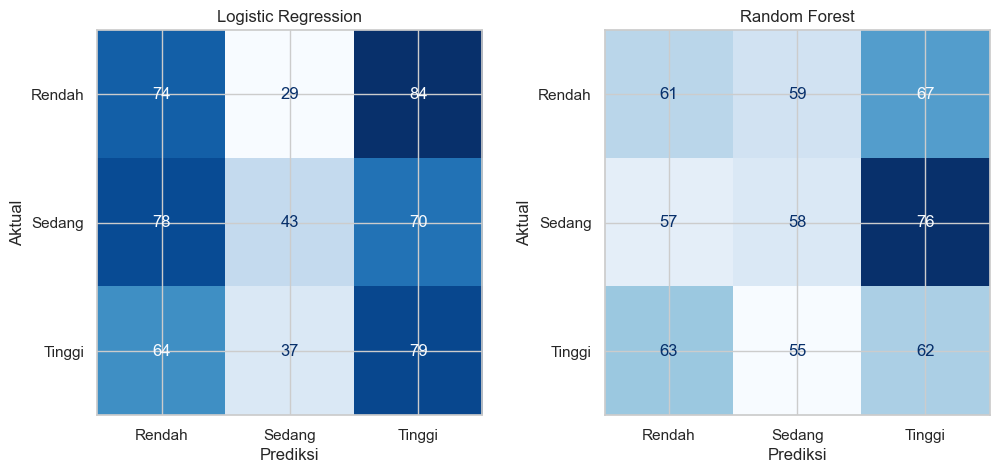

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, m) in zip(axes, test_metrics.items()):
    
    cm = confusion_matrix(y_test, m['pred'], labels=CLASS_ORDER)
    
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    
    ax.set_title(name)
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.show()

ROC Curve

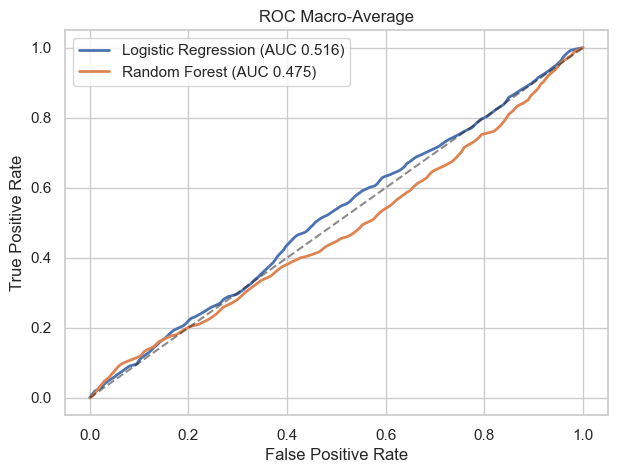

In [17]:
yb = label_binarize(y_test, classes=CLASS_ORDER)
grid = np.linspace(0, 1, 200)

plt.figure(figsize=(7, 5))

for name, m in test_metrics.items():
    
    tpr_list = []
    
    for i in range(3):
        fpr_i, tpr_i, _ = roc_curve(yb[:, i], m['proba'][:, i])
        tpr_terinterpolasi = np.interp(grid, fpr_i, tpr_i)
        tpr_list.append(tpr_terinterpolasi)
        
    tpr = np.mean(tpr_list, axis=0)
    
    auc = roc_auc_score(
        y_test, 
        m['proba'], 
        multi_class='ovr', 
        average='macro', 
        labels=CLASS_ORDER
    )
    
    plt.plot(grid, tpr, lw=2, label=f'{name} (AUC {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Macro-Average')
plt.legend()

plt.show()

### 7.3 Kestabilan CV dan cek overfitting

Kiri: akurasi tiap lipatan untuk melihat kestabilan. Kanan: akurasi latih versus uji; selisih yang lebar menandakan overfitting.

NameError: name 'colors' is not defined

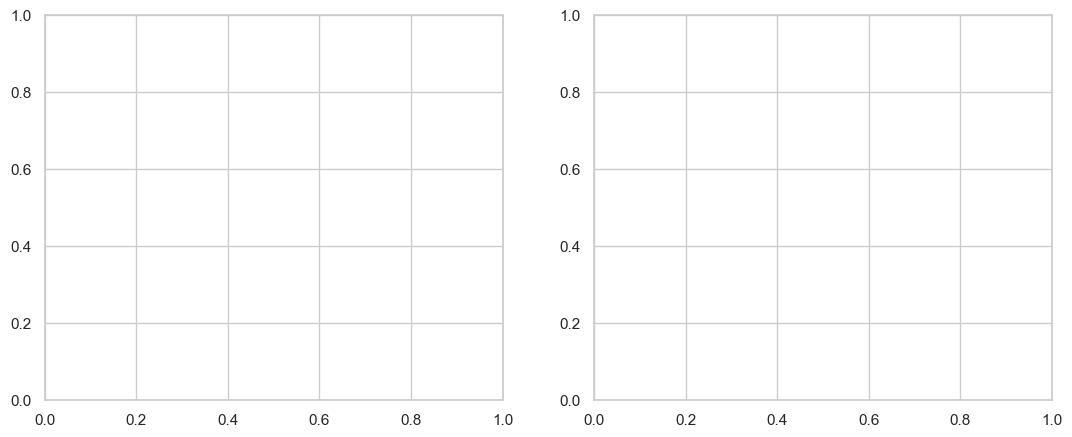

In [19]:
fig, (a, b) = plt.subplots(1, 2, figsize=(13, 5))

for name, c in zip(models, colors):
    v = cv_results[name]['test_accuracy']
    
    a.plot(range(1, 6), v, 'o-', color=c, label=name)
    a.axhline(v.mean(), ls='--', color=c, alpha=0.4)

a.set_title('Akurasi CV per fold')
a.set_xlabel('Fold')
a.set_ylabel('Accuracy')
a.set_xticks(range(1, 6))
a.legend()

tr = [cv_results[n]['train_accuracy'].mean() for n in models]
te = [test_metrics[n]['acc'] for n in models]

x = np.arange(len(models))

b.bar(x - 0.18, tr, 0.32, label='Train (CV)', color=colors, alpha=0.45)
b.bar(x + 0.18, te, 0.32, label='Test', color=colors, alpha=1.0)

b.set_xticks(x)
b.set_xticklabels(list(models))
b.set_ylim(0, 1.12)
b.set_ylabel('Accuracy')
b.set_title('Train vs test')
b.legend()

plt.tight_layout()
plt.show()

## 8. Train vs test Accuracy

In [ ]:
print(f"{'Model':22s}{'Train':>8s}{'Test':>8s}")
for n in test_metrics:
    train_acc = cv_results[n]['train_accuracy'].mean()
    print(f"{n:22s}{train_acc:8.3f}{test_metrics[n]['acc']:8.3f}")

Model                    Train    Test
Logistic Regression      0.365   0.351
Random Forest            0.429   0.324


## 9. Save model


In [ ]:
# import joblib

# joblib.dump(fitted['Random Forest'],       'rf_pipeline_paddy.joblib')
# joblib.dump(fitted['Logistic Regression'], 'lr_pipeline_paddy.joblib')
# joblib.dump(fitur_app,                     'fitur_aplikasi.joblib')

# kolom = joblib.load('fitur_aplikasi.joblib')
# contoh = X_test[kolom].iloc[[0]]
# print("Aktual:", y_test.iloc[0], "\n")
# for nama, fname in [('Random Forest', 'rf_pipeline_paddy.joblib'),
#                     ('Logistic Regression', 'lr_pipeline_paddy.joblib')]:
#     m = joblib.load(fname)
#     proba = {k: round(float(v), 3) for k, v in zip(m.classes_, m.predict_proba(contoh)[0])}
#     print(f"{nama:20s} -> prediksi: {m.predict(contoh)[0]} | probabilitas: {proba}")

Aktual: Sedang 

Random Forest        -> prediksi: Tinggi | probabilitas: {'Rendah': 0.308, 'Sedang': 0.298, 'Tinggi': 0.394}
Logistic Regression  -> prediksi: Tinggi | probabilitas: {'Rendah': 0.301, 'Sedang': 0.317, 'Tinggi': 0.382}
